## Simple RNN for forecasting

In [1]:
import os
# Set TF's logging level to suppress 'INFO' messages (like the ones shown)
# '3' is ERROR, '2' is WARNING, '1' is INFO (default is often 0 or 1)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

### Utilities

In [2]:
def plot_series(time, series, format="-", start=0, end=None):
    """
    Visualizes time series data

    Args:
      time (array of int) - contains the time steps
      series (array of int) - contains the measurements for each time step
      format - line style when plotting the graph
      start - first time step to plot
      end - last time step to plot
    """

    # Setup dimensions of the graph figure
    plt.figure(figsize=(10, 6))

    if type(series) is tuple:

      for series_num in series:
        # Plot the time series data
        plt.plot(time[start:end], series_num[start:end], format)

    else:
      # Plot the time series data
      plt.plot(time[start:end], series[start:end], format)

    # Label the x-axis
    plt.xlabel("Time")

    # Label the y-axis
    plt.ylabel("Value")

    # Overlay a grid on the graph
    plt.grid(True)

    # Draw the graph on screen
    plt.show()

def trend(time, slope=0):
    """
    Generates synthetic data that follows a straight line given a slope value.

    Args:
      time (array of int) - contains the time steps
      slope (float) - determines the direction and steepness of the line

    Returns:
      series (array of float) - measurements that follow a straight line
    """

    # Compute the linear series given the slope
    series = slope * time

    return series

def seasonal_pattern(season_time):
    """
    Just an arbitrary pattern, you can change it if you wish

    Args:
      season_time (array of float) - contains the measurements per time step

    Returns:
      data_pattern (array of float) -  contains revised measurement values according
                                  to the defined pattern
    """

    # Generate the values using an arbitrary pattern
    data_pattern = np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

    return data_pattern

def seasonality(time, period, amplitude=1, phase=0):
    """
    Repeats the same pattern at each period

    Args:
      time (array of int) - contains the time steps
      period (int) - number of time steps before the pattern repeats
      amplitude (int) - peak measured value in a period
      phase (int) - number of time steps to shift the measured values

    Returns:
      data_pattern (array of float) - seasonal data scaled by the defined amplitude
    """

    # Define the measured values per period
    season_time = ((time + phase) % period) / period

    # Generates the seasonal data scaled by the defined amplitude
    data_pattern = amplitude * seasonal_pattern(season_time)

    return data_pattern

def noise(time, noise_level=1, seed=None):
    """Generates a normally distributed noisy signal

    Args:
      time (array of int) - contains the time steps
      noise_level (float) - scaling factor for the generated signal
      seed (int) - number generator seed for repeatability

    Returns:
      noise (array of float) - the noisy signal
    """

    # Initialize the random number generator
    rnd = np.random.RandomState(seed)

    # Generate a random number for each time step and scale by the noise level
    noise = rnd.randn(len(time)) * noise_level

    return noise

### Generate the Synthetic Data

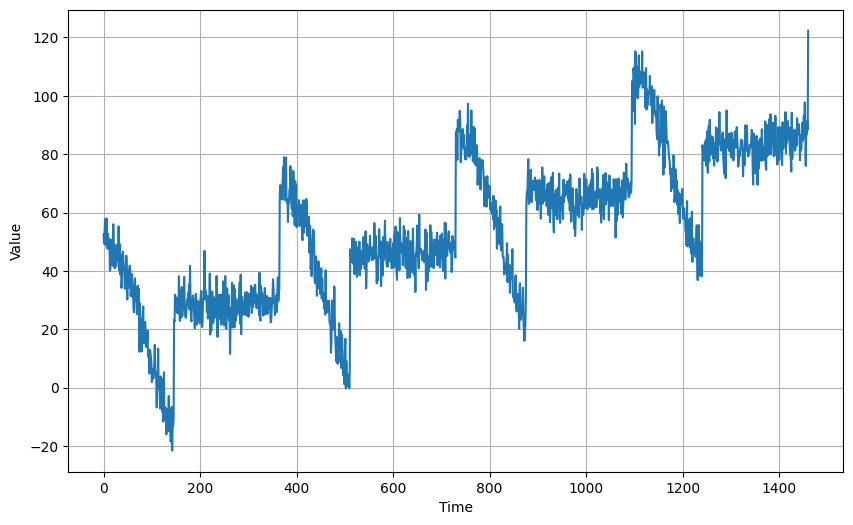

In [3]:
# Parameters
time = np.arange(4 * 365 + 1, dtype="float32")
baseline = 10
amplitude = 40
slope = 0.05
noise_level = 5

# Create the series
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

# Update with noise
series += noise(time, noise_level, seed=42)

# Plot the results
plot_series(time, series)

### Split dataset

In [4]:
# Define the split time
split_time = 1000

# Get the train set
time_train = time[:split_time]
x_train = series[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = series[split_time:]

### Prepare features and labels

In [5]:
# Parameters
window_size = 20
batch_size = 32
shuffle_buffer_size = 1000

You will be using `SimpleRNN` layers later and as mentioned in its [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN#call_arguments), these expect a 3-dimensional tensor input with the shape `[batch, timesteps, feature`]. With that, you need to reshape your window from `(32, 20)` to `(32, 20, 1)`. This means the 20 data points in the window will be mapped to 20 timesteps of the RNN. To implement this, you will add an `expand_dims()` to the `windowed_dataset()` function you used in the previous labs.

_Note: Technically, you will only need this extra line if you don't specify the input shape as you will do later when you build the model. Nonetheless, it is best practice to define transformations like this, especially in data pipelines. It can help make debugging easier in case you have problems later on._

In [6]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float/Numpy array) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """

    # Add an axis for the feature dimension
    series = tf.expand_dims(series, axis=-1)

    # Generate the tf.data.Dataset from the series
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Create a windowed dataset but only take those with the specified size (remove the last left over)
    dataset = dataset.window(window_size+1, shift=1, drop_remainder=True)

    # Flatten the window by putting elements into single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels - Apply transformation to every single windowed dataset
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle
    dataset = dataset.shuffle(shuffle_buffer)

    # Create batches of windows
    dataset = dataset.batch(batch_size)
    dataset = dataset.cache().prefetch(1)
    return dataset

In [7]:
dataset = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

In [8]:
for window in dataset.take(1):
    print(f"Shape of feature: {window[0].shape}")
    print(f"Shape of label: {window[1].shape}")
    print(f"Data itself: {window}")

Shape of feature: (32, 20, 1)
Shape of label: (32, 1)
Data itself: (<tf.Tensor: shape=(32, 20, 1), dtype=float32, numpy=
array([[[46.375916  ],
        [54.080563  ],
        [55.38649   ],
        [40.739193  ],
        [43.049755  ],
        [38.197876  ],
        [46.469997  ],
        [50.822926  ],
        [54.160572  ],
        [46.428406  ],
        [53.605907  ],
        [37.963173  ],
        [35.743767  ],
        [43.376278  ],
        [44.964203  ],
        [42.267     ],
        [31.476778  ],
        [40.74903   ],
        [34.05024   ],
        [43.29642   ]],

       [[31.563684  ],
        [30.338299  ],
        [27.586983  ],
        [23.696756  ],
        [20.336658  ],
        [25.659061  ],
        [32.15494   ],
        [28.925291  ],
        [21.608559  ],
        [28.686138  ],
        [29.73035   ],
        [23.368555  ],
        [28.541082  ],
        [28.048655  ],
        [22.028439  ],
        [29.518435  ],
        [30.52015   ],
        [33.118732  ],
   

### Explanation of the features shape <br>

![image.png](attachment:image.png)

<br>
Detailed Breakdown

1. 32: The Batch Size
This means the tensor contains 32 complete time windows. When the model trains, it doesn't process one data point at a time; it processes a batch of 32 windows simultaneously. This is done for efficiency and smoother gradient estimation during training.

2. 20: The Window Size (Time Steps)
This is the core of the time series preparation. Each of the 32 samples is a sequence of 20 consecutive time steps (e.g., t−19,t−18,…,t−1). This sequence of 20 values is the historical context the model uses to learn to predict the next value.

3. 1: The Feature Dimension
This dimension indicates that the time series is univariate, meaning it only contains values for a single variable (e.g., only temperature, only stock price, only sales count). If you were tracking multiple related variables (e.g., temperature, humidity, and pressure), this dimension would be 3 (multivariate time series), and the shape would be (32, 20, 3).

### Build the model

<br>

Your model is composed mainly of [SimpleRNN](https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN) layers. As mentioned in the lectures, this type of RNN simply routes its output back to the input. You will stack two of these layers in your model so the first one should                    have `return_sequences` set to `True`.

Normally, you can just have a `Dense` layer output as shown in the previous labs. However, you can help the training by scaling up the output to around the same figures as your labels. This will depend on the [activation functions](https://en.wikipedia.org/wiki/Activation_function#Table_of_activation_functions) you used in your model. `SimpleRNN` uses *tanh* by default and that has an output range of `[-1,1]`. You will use a `Lambda` layer to scale the output by 100 before it adjusts the layer weights. `Lambda` layers can be a useful tool to experiment with simple transformations like this. Feel free to remove this layer later after this lab and see what results you get.

In [9]:
input_layer = tf.keras.Input(shape=(window_size, 1))
x = tf.keras.layers.SimpleRNN(40, return_sequences=True)(input_layer)
x = tf.keras.layers.SimpleRNN(40)(x)
x = tf.keras.layers.Dense(1)(x)
output_layer = tf.keras.layers.Lambda(lambda x: x*100.0)(x)

model = tf.keras.Model(input_layer, output_layer)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 20, 40)         │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            41 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,961 (19.38 KB)

 Trainable params: 4,961 (19.38 KB)

 Non-trainable params: 0 (0.00 B)

### Tune the learning rate

In [11]:
# Set the learning rate scheduler
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-8 * 10**(epoch / 20))

optimizer = tf.keras.optimizers.SGD(momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer)
history = model.fit(dataset, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 60.9253 - learning_rate: 1.0000e-08
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 58.4857 - learning_rate: 1.1220e-08


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 55.0390 - learning_rate: 1.2589e-08
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 50.5572 - learning_rate: 1.4125e-08
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 44.4440 - learning_rate: 1.5849e-08
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.5275 - learning_rate: 1.7783e-08
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29.1099 - learning_rate: 1.9953e-08
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.4457 - learning_rate: 2.2387e-08
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.0584 - learning_rate: 2.5119e-08
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.3165 - learning_rate: 2.8184e-08
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.7828 - learning_rate: 3.1623e-08
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.0947 - learning_rate: 3.5481e-08
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

(np.float64(1e-08), np.float64(0.001), np.float64(0.0), np.float64(50.0))

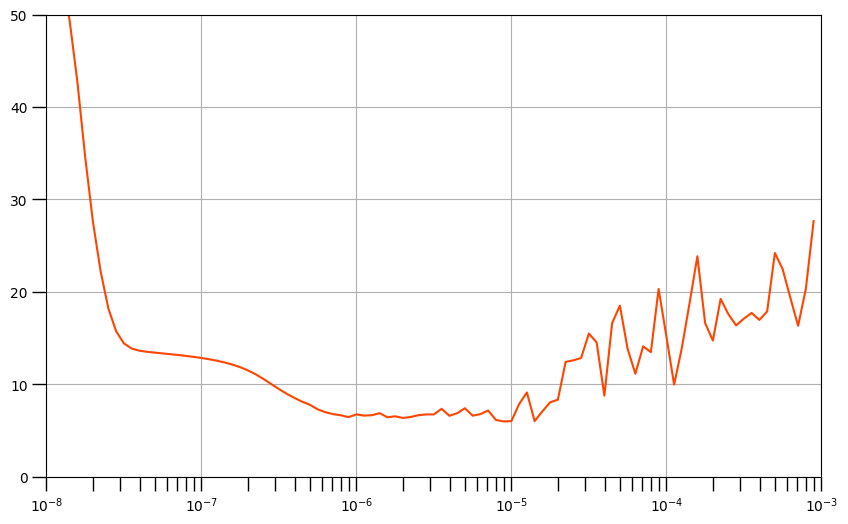

In [12]:
lrs = 1e-8 * (10 ** (np.arange(100) / 20))
# Set the figure size
plt.figure(figsize=(10, 6))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"], color="orangered")

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-8, 1e-3, 0, 50])

(np.float64(1e-07), np.float64(0.0001), np.float64(0.0), np.float64(20.0))

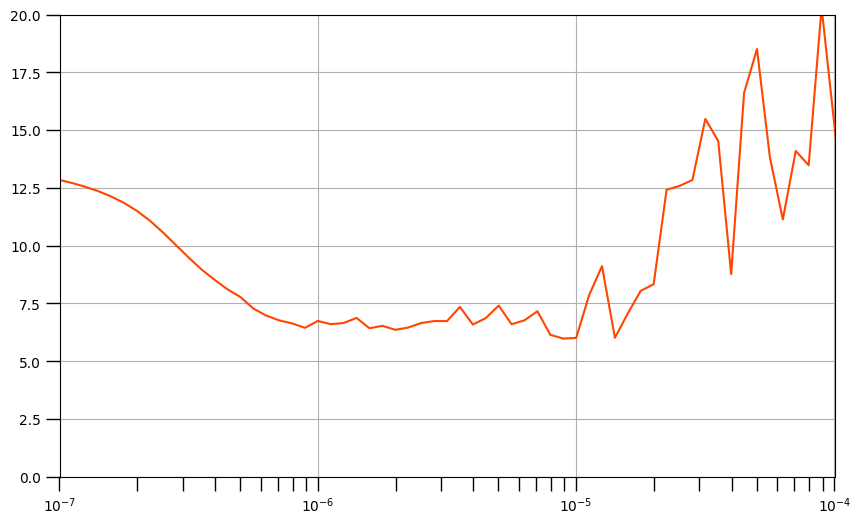

In [13]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Set the grid
plt.grid(True)

# Plot the loss in log scale
plt.semilogx(lrs, history.history["loss"], color="orangered")

# Increase the tickmarks size
plt.tick_params('both', length=10, width=1, which='both')

# Set the plot boundaries
plt.axis([1e-7, 1e-4, 0, 20])

In [14]:
input_layer = tf.keras.Input(shape=(window_size, 1))
x = tf.keras.layers.SimpleRNN(40, return_sequences=True)(input_layer)
x = tf.keras.layers.SimpleRNN(40)(x)
x = tf.keras.layers.Dense(1)(x)
output_layer = tf.keras.layers.Lambda(lambda x: x*100.0)(x)

model_tuned = tf.keras.Model(input_layer, output_layer)

optimizer = tf.keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9)
model_tuned.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer, metrics=['mae'])
history = model_tuned.fit(dataset, epochs=100)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 121.3732 - mae: 121.8727
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.9249 - mae: 21.4196
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.7319 - mae: 17.2237
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.4084 - mae: 14.8993
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.8403 - mae: 12.3274
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.6625 - mae: 11.1462
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.9096 - mae: 10.3972
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.3553 - mae: 9.8407
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.8363 - mae: 9.3232
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.4049 - mae: 8.8921
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0469 - mae: 8.5341
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7648 - mae: 8.2512
Epoch 13/100
31/31 ━━

## Model Prediction

Generate model predictions for the validation set time range

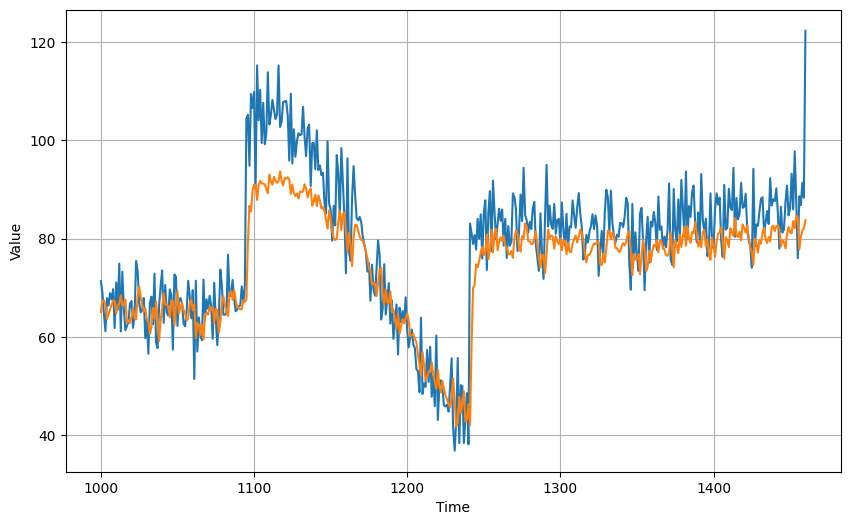

In [15]:
forecast = []

forecast_series = series[split_time - window_size:]
for time in range(len(forecast_series)-window_size):
  forecast.append(model_tuned.predict(forecast_series[time:time+window_size][np.newaxis], verbose=0))

results = np.array(forecast).squeeze()
# Plot the results
plot_series(time_valid, (x_valid, results))

In [16]:
def model_forecast(model, series, window_size, batch_size):
    """Uses an input model to generate predictions on data windows

    Args:
      model (TF Keras Model) - model that accepts data windows
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the window
      batch_size (int) - the batch size

    Returns:
      forecast (numpy array) - array containing predictions
    """

    # Add an axis for the feature dimension of RNN layers
    series = tf.expand_dims(series, axis=-1)

    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)

    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda w: w.batch(window_size))

    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)

    # Get predictions on the entire dataset
    forecast = model.predict(dataset, verbose=0)

    return forecast

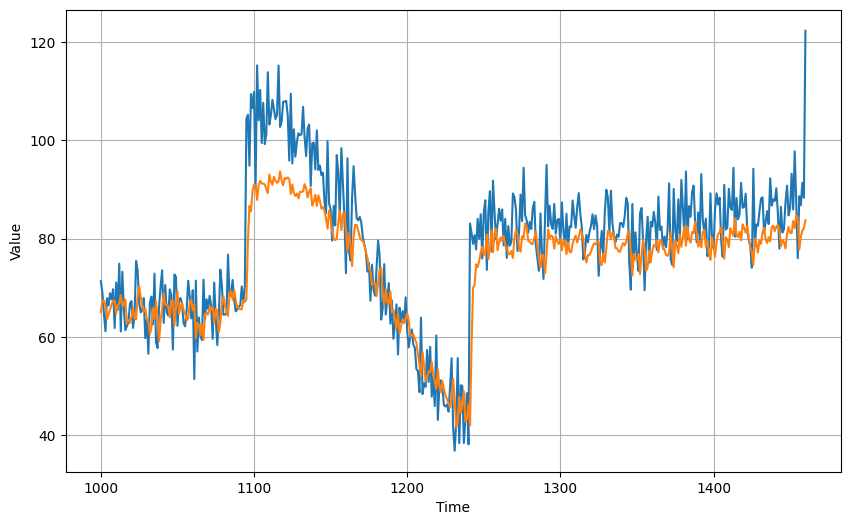

In [17]:
# Only needed in this lab. Reset the model but keep the trained weights to prepare for batched inputs.
model_tuned.compile(loss=tf.keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# Reduce the original series
forecast_series = series[split_time - window_size:-1]

# Use helper function to generate predictions
forecast = model_forecast(model_tuned, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

# Plot the results
plot_series(time_valid, (x_valid, results))

In [18]:
# Compute the MSE and MAE
print(tf.keras.metrics.mse(x_valid, results).numpy())
print(tf.keras.metrics.mae(x_valid, results).numpy())

70.71904
6.2643986
